In [117]:
import pandas as pd
df = pd.read_csv('customer_journey.csv', encoding='1251')

In [118]:
df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [119]:
df.shape

(12719, 10)

In [120]:
df.isna().any()

SessionID             False
UserID                False
Timestamp             False
PageType              False
DeviceType            False
Country               False
ReferralSource        False
TimeOnPage_seconds    False
ItemsInCart           False
Purchased             False
dtype: bool

In [121]:
df['TimeOnPage_seconds'].unique()

array([ 55,  99, 121, 160, 113,  49, 135, 155,  26,  15, 130, 145,  61,
       129,  93, 137, 112, 153,  75, 116,  54,  81,  31, 147,  92,  42,
       171, 144,  77, 178, 163,  47,  78, 104,  51, 142,  58, 150,  34,
       119,  84,  32, 167,  63, 149, 176,  20,  89, 151, 180,  69,  33,
       131, 141, 136, 123, 108, 115,  35, 128, 118, 166,  57, 140, 174,
        95,  97, 148, 173,  27, 114,  43,  46, 162,  30,  85,  94, 177,
        39,  25,  80, 133, 102, 152, 124, 146,  91,  37, 138,  82, 120,
       106,  19,  66,  60,  79,  67,  72, 134,  74,  24,  45,  29, 158,
        44,  86,  17,  38,  21, 172,  28, 154,  90, 126, 132, 100, 111,
       170, 139, 164,  62,  73, 179,  48, 110,  40,  56, 165,  18,  50,
       157,  16, 109,  22, 169,  36,  65, 117, 175, 143,  64,  71, 161,
        88, 168,  76,  23,  53, 101, 127, 122,  98, 156,  41, 159,  52,
        83,  70,  68, 105, 125, 103,  87,  59,  96, 107])

In [122]:
df.Purchased.value_counts(normalize=True)

Purchased
0    0.602956
1    0.397044
Name: proportion, dtype: float64

In [123]:
df.groupby('SessionID').filter(lambda x: (x['Purchased'] == 1).any()).head(15)

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
7,session_5,user_2216,2025-01-08 20:58:18,home,Desktop,UK,Email,155,0,1
8,session_5,user_2216,2025-01-08 20:59:57,product_page,Desktop,UK,Email,99,0,1
9,session_5,user_2216,2025-01-08 21:00:23,cart,Desktop,UK,Email,26,5,1
10,session_5,user_2216,2025-01-08 21:00:38,checkout,Desktop,UK,Email,15,5,1
11,session_5,user_2216,2025-01-08 21:02:48,confirmation,Desktop,UK,Email,130,0,1
40,session_18,user_1797,2025-05-11 10:48:00,home,Mobile,USA,Email,78,0,1
41,session_18,user_1797,2025-05-11 10:49:44,product_page,Mobile,USA,Email,104,0,1
42,session_18,user_1797,2025-05-11 10:50:35,cart,Mobile,USA,Email,51,0,1
43,session_18,user_1797,2025-05-11 10:52:57,checkout,Mobile,USA,Email,142,2,1
44,session_18,user_1797,2025-05-11 10:53:55,confirmation,Mobile,USA,Email,58,0,1


**Путь пользователя, если он совершил покупку и изначально в его корзине пусто:** 

home -> выбор продукта -> product_page -> выбор продукта -> cart -> выбор продукта -> checkout (ItemsInCart всегда > 0) -> confirmation (ItemsInCart всегда = 0)

**Вопросы для построения гипотезы:**

**вопрос 1.** какой источник трафика (ReferralSource) приносит наибольшую долю покупателей?

**вопрос 2.** сколько в среднем сеансов необходимо пользователю, чтобы в итоге совершить хотя бы одну покупку?

**вопрос 3.** сколько секунд требуется пользователю на то, чтобы определиться, нужен ли ему продукт? (количество секунд на странице checkout)

In [124]:
unique_sessions = df[['SessionID', 'ReferralSource', 'Purchased']].drop_duplicates(subset='SessionID')

conversion_by_source = (
    unique_sessions
    .groupby('ReferralSource')
    .agg(
        total_sessions=('SessionID', 'count'),
        purchased_sessions=('Purchased', 'sum') 
    )
    .assign(conversion_rate=lambda x: x['purchased_sessions'] / x['total_sessions'])
    .sort_values('conversion_rate', ascending=False)
)

conversion_by_source

,total_sessions,purchased_sessions,conversion_rate
ReferralSource,,,
Google,1280,277,0.216406
Email,1251,251,0.200639
Direct,1226,243,0.198206
Social Media,1243,239,0.192277


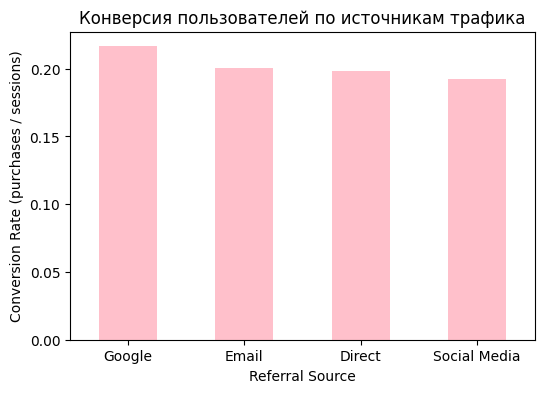

In [125]:
import matplotlib.pyplot as plt

conversion_by_source['conversion_rate'].plot(kind='bar', figsize=(6,4), color = 'pink')
plt.title('Конверсия пользователей по источникам трафика')
plt.ylabel('Conversion Rate (purchases / sessions)')
plt.xlabel('Referral Source')
plt.xticks(rotation=0)
plt.show()

**Google** приносит наибольшую долю покупателей, **Social Media** - наименьшую

In [126]:
unique_sessions_users = df[['UserID', 'SessionID', 'Purchased']].drop_duplicates(subset='SessionID')

user_stats = (
    unique_sessions_users
    .groupby('UserID')
    .agg(
        total_sessions=('SessionID', 'count'),   
        is_buyer=('Purchased', 'max')            
    )
    .reset_index()
)
user_stats

,UserID,total_sessions,is_buyer
0,user_1001,2,1
1,user_1002,2,1
2,user_1004,1,0
3,user_1005,2,1
4,user_1006,4,0
...,...,...,...
1867,user_2997,5,0
1868,user_2998,1,0
1869,user_2999,3,1
1870,user_3000,3,1


In [127]:
avg_sessions_buyers = user_stats[user_stats['is_buyer'] == 1]['total_sessions'].mean()
avg_sessions_non_buyers = user_stats[user_stats['is_buyer'] == 0]['total_sessions'].mean()
avg_sessions_overall = user_stats['total_sessions'].mean()

print(f"cреднее количество сессий на пользователя, который совершил покупку: {avg_sessions_buyers:.2f}")
print(f"cреднее количество сессий на пользователя, который НЕ совершил покупку: {avg_sessions_non_buyers:.2f}")
print(f"cреднее количество сессий на всех пользователей: {avg_sessions_overall:.2f}")

cреднее количество сессий на пользователя, который совершил покупку: 3.26
cреднее количество сессий на пользователя, который НЕ совершил покупку: 2.24
cреднее количество сессий на всех пользователей: 2.67


количество сессий на пользователя, который совершил покупку, в среднем **выше на 1**, чем количество сессий на пользователя, который НЕ совершил покупку

In [128]:
checkout_events = df[df['PageType'] == 'checkout'].copy()

mean_time = checkout_events['TimeOnPage_seconds'].mean()
median_time = checkout_events['TimeOnPage_seconds'].median()

print(f"cреднее время на checkout (все события): {mean_time:.2f} сек")
print(f"медианное время на checkout (все события): {median_time:.2f} сек")
print(f"количество событий checkout: {len(checkout_events)}")

cреднее время на checkout (все события): 96.61 сек
медианное время на checkout (все события): 98.00 сек
количество событий checkout: 1123


In [129]:
mean_buyers = checkout_events[checkout_events['Purchased'] == 1]['TimeOnPage_seconds'].mean()
mean_nonbuyers = checkout_events[checkout_events['Purchased'] == 0]['TimeOnPage_seconds'].mean()

print(f"среднее время на checkout у покупателей: {mean_buyers:.2f} сек")
print(f"среднее время на checkout у не-покупателей: {mean_nonbuyers:.2f} сек")

# суммарное время на checkout за сессию (если в сессии несколько посещений checkout)
total_per_session = checkout_events.groupby('SessionID')['TimeOnPage_seconds'].sum().mean()
print(f"\nсреднее суммарное время на checkout за сессию: {total_per_session:.2f} сек")

среднее время на checkout у покупателей: 96.46 сек
среднее время на checkout у не-покупателей: 97.88 сек

среднее суммарное время на checkout за сессию: 96.61 сек


**существенных различий во времени, проведенном на странице checkout, между покупателями и НЕ-покупателями нет**

In [130]:
len(df['UserID'].unique())

1872

In [131]:
steps = ['home', 'product_page', 'cart', 'checkout']

session_pages = df.groupby('SessionID')['PageType'].unique().reset_index()
session_pages.columns = ['SessionID', 'pages']

# число сессий, где этап присутствует
step_counts = {}
for step in steps:
    count = session_pages['pages'].apply(lambda x: step in x).sum()
    step_counts[step] = count

funnel_df = pd.DataFrame({
    'Stage': steps,
    'Sessions': [step_counts[step] for step in steps]
})

total_start = funnel_df.loc[funnel_df['Stage'] == 'home', 'Sessions'].values[0]
funnel_df['% of home'] = (funnel_df['Sessions'] / total_start * 100).round(1)

funnel_df['% drop_off'] = 0.0
for i in range(1, len(funnel_df)):
    prev = funnel_df.loc[i-1, 'Sessions']
    curr = funnel_df.loc[i, 'Sessions']
    drop = (prev - curr) / prev * 100
    funnel_df.loc[i, '% drop_off'] = round(drop, 1)

print(funnel_df.to_string(index=False))

       Stage  Sessions  % of home  % drop_off
        home      5000      100.0         0.0
product_page      3987       79.7        20.3
        cart      1599       32.0        59.9
    checkout      1123       22.5        29.8


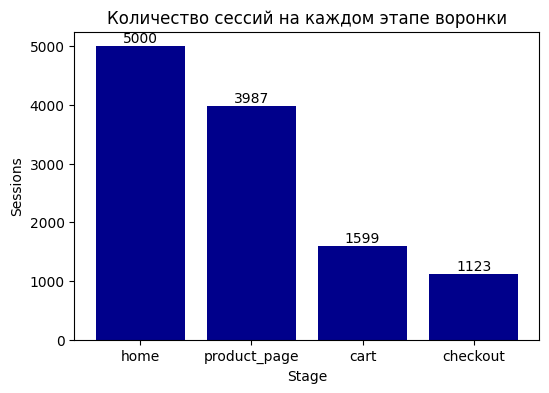

In [132]:
plt.figure(figsize=(6, 4))
plt.bar(funnel_df['Stage'], funnel_df['Sessions'], color='darkblue')
plt.title('Количество сессий на каждом этапе воронки')
plt.ylabel('Sessions')
plt.xlabel('Stage')
for i, v in enumerate(funnel_df['Sessions']):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')
plt.show()

**ГИПОТЕЗА:**

Персонализированное промо-предложение (скидка или бонус), отправленное через push-уведомление пользователям, которые пришли из Social Media, увеличит конверсию в покупку как минимум на 3 процентных пункта (с текущих ~19.2% до 22.2%) по сравнению с контрольной группой, которая не получит никаких дополнительных коммуникаций.

In [135]:
import math
from scipy.stats import norm

p_c = 0.192          
mde = 0.03            
p_t = p_c + mde   

alpha = 0.05          
beta = 0.20          
power = 1 - beta    

# квантили для одностороннего теста (right-sided)
z_alpha = norm.ppf(1 - alpha)   # 1.645
z_beta = norm.ppf(1 - beta)     # 0.842

# дисперсии (p*(1-p))
var_c = p_c * (1 - p_c)
var_t = p_t * (1 - p_t)

# размер выборки на одну группу
N_group = ((z_alpha + z_beta) ** 2 * (var_c + var_t)) / (mde ** 2)

# общий размер (обе группы)
N_total = 2 * N_group

print(f"размер на группу: {math.ceil(N_group)}")
print(f"общий размер выборки: {math.ceil(N_total)}")

размер на группу: 2253
общий размер выборки: 4505


In [ ]:
ab_test_design = {
    "experiment": {
        # общее название теста
        "name": "Влияние пуш-промо на конверсию пользователей из Social Media",
        # бизнес-цель теста
        "business_goal": "Повысить конверсию в покупку среди пользователей, пришедших из социальных сетей",
        # описание воздействия
        "treatment": "Отправка пуш-уведомления с персональным промо-кодом",
        # гипотеза (бизнесовая)
        "hypothesis": "Пуш с промо-кодом увеличит конверсию в покупку на 3 п.п. (с 19.2% до 22.2%) по сравнению с контрольной группой без коммуникаций"
    },
    "population": {
        # критерии попадания объектов в выборку 
        "include": [
            "Пользователи, у которых последний ReferralSource = 'Social Media'",
            "Активны в приложении за последние 30 дней",
            "Пуш-уведомления включены",
            "Совершили хотя бы одну сессию за последние 7 дней"
        ],
        # критерии исключения объектов из выборки
        "exclude": [
            "Сотрудники компании",
            "Пользователи из «Вечного Контроля» маркетинговых тестов",
            "Те, кто уже получил промо-предложение за последние 30 дней"
        ]
    },
    "randomization": {
        # единица рандомизации
        "unit": "user_id",
        # сплит трафика по группам теста
        "allocation": {
            "Control": 0.50,
            "Treatment": 0.50
        }
    },
    "variants_description": {   # описание воздействия в тестовых вариациях (группах)
        "Control": "Пользователи не получают никаких дополнительных коммуникаций",
        "Treatment": "Пользователи получают пуш с текстом: «Специально для вас - скидка 10% на первый заказ! Действует 3 дня.»"
    },
        # блок метрик
    "metrics": {
        "primary": [
            {
                # название метрики
                "name": "Конверсия в покупку (за сессию)",
                # более подробное описание метрики
                "definition": "Наличие хотя бы одной покупки (Purchased = 1) в течение 7 дней после отправки пуша",
                # тип метрики
                "type": "binary"
            }
        ],
        "secondary": [
            {
                "name": "Выручка на пользователя за 7 дней",
                "definition": "Суммарная выручка от покупок пользователя в течение 7 дней после отправки",
                "type": "continuous"
            },
            {
                "name": "Open Rate пуша",
                "definition": "Доля пользователей, открывших push-уведомление в течение 24 часов",
                "type": "binary"
            },
            {
                "name": "Количество сессий за 7 дней",
                "definition": "Среднее число сессий после отправки (проверка вовлечённости)",
                "type": "continuous"
            }
        ],
        "guardrail": [
            {
                "name": "Отписка от push-уведомлений",
                "definition": "Доля пользователей, отключивших push в течение 7 дней",
                "type": "binary"
            },
            {
                "name": "Частота жалоб на акцию",
                "definition": "Доля пользователей, обратившихся в поддержку с вопросами или жалобами по поводу промо-кода или скидки, за 7 дней после отправки пуша.",
                "type": "binary"
            }
        ]
    },
    "statistical_design": {
        # статистический критерий
        "method": "two-proportion z-test",
        "alpha": 0.05,                 
        "beta": 0.20,
        "alternative": "larger",        
        "baseline_value": 0.192,        # текущая конверсия для Social Media 
        # MDE
        "minimum_detectable_effect": 0.03,
        # ожидаемое количество наблюдений
        "expected_sample_size": 4505,        # 2253 на группу (с запасом)
        "estimated_days": 14                 # 7 дней на отправку + 7 дней наблюдения
    },
    "risks": [
        # перечисление рисков, связанных с запуском или подведением аналитики теста
        "Возможное влияние параллельных маркетинговых акций (например, сезонные распродажи)",
        "Технические проблемы с доставкой push-уведомлений (задержки, ошибки)",
        "Пользователи могут получать предложения из других каналов (email, чат), что исказит результаты",
        "Сезонность: если тест проводится в период высокого спроса, эффект может быть переоценён"
    ]}